# MNIST One-vs-All Classification 

## Environment Setup

In [82]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler
from sklearn.datasets import fetch_openml
import seaborn as sns

## Config

In [83]:
RANDOM_STATE = 2
LEARNING_RATE = 0.1
EPOCHS = 20
BATCH_SIZE = 256
VAL_SPLIT = 0.2
TEST_SPLIT = 0.125

## Dataset Loading & EDA

In [84]:
mnist = fetch_openml('mnist_784', version=1)

X, y = mnist.data, mnist.target

print(X.shape, y.shape)

(70000, 784) (70000,)


In [85]:
print(X[:5])

   pixel1  pixel2  pixel3  pixel4  ...  pixel781  pixel782  pixel783  pixel784
0       0       0       0       0  ...         0         0         0         0
1       0       0       0       0  ...         0         0         0         0
2       0       0       0       0  ...         0         0         0         0
3       0       0       0       0  ...         0         0         0         0
4       0       0       0       0  ...         0         0         0         0

[5 rows x 784 columns]


In [86]:
print(y[:5])
print(type(y[0]))

0    5
1    0
2    4
3    1
4    9
Name: class, dtype: category
Categories (10, str): ['0', '1', '2', '3', ..., '6', '7', '8', '9']
<class 'str'>


## Data Preparation

In [87]:
X = np.hstack([np.ones((X.shape[0], 1)), X])
y = np.array([int(label) for label in y])

y_onehot = []

for label in y:
    one_hot = np.zeros(10)
    one_hot[label] = 1
    y_onehot.append(one_hot)

y_onehot = np.array(y_onehot)

In [88]:
X_trainval, X_val, y_trainval, y_val, y_onehot_trainval, y_onehot_val = train_test_split(
    X, y, y_onehot, test_size=VAL_SPLIT, stratify=y, random_state=RANDOM_STATE
)
X_train, X_test, y_train, y_test, y_onehot_train, y_onehot_test = train_test_split(
    X_trainval, y_trainval, y_onehot_trainval, test_size=TEST_SPLIT, stratify=y_trainval, random_state=RANDOM_STATE
)

In [89]:
print(f"Train size: {len(X_train) / len(X) * 100:.1f}%")
print(f"Val size:   {len(X_val) / len(X) * 100:.1f}%")
print(f"Test size:  {len(X_test) / len(X) * 100:.1f}%")

Train size: 70.0%
Val size:   20.0%
Test size:  10.0%


## Normalization

In [90]:
scaler = StandardScaler()

X_train[:, 1:] = scaler.fit_transform(X_train[:, 1:])
X_val[:, 1:] = scaler.transform(X_val[:, 1:])
X_test[:, 1:] = scaler.transform(X_test[:, 1:])

## Helper Functions

In [91]:
def sigmoid(z):
    return 1 / (1 + np.exp(-z))

In [92]:
def OvA_predict(X, theta):

    logits = X @ theta

    y_hat = sigmoid(logits)

    return y_hat

In [93]:
def OvA_compute_loss(y_pred, y_onehot):

    y_pred = np.clip(y_pred, 1e-7, 1 - 1e-7)

    loss = np.mean(-y_onehot * np.log(y_pred) - (1 - y_onehot) * np.log(1 - y_pred))

    return loss

In [94]:
def OvA_compute_gradient(X, y_onehot, y_pred):
    gradient = (X.T @ (y_pred - y_onehot)) / len(X) 

    return gradient

In [95]:
def update_theta(theta, gradient, lr):
    return theta - lr * gradient

In [96]:
def compute_accuracy(y_pred, y_true):

    preds = np.argmax(y_pred, axis=1)
    correct = np.sum(y_true == preds)

    accuracy = correct / y_true.shape[0]

    return accuracy

## Training Loop

In [100]:
theta = np.zeros((X_train.shape[1], 10))
train_losses, val_losses, train_accs, val_accs = [], [], [], []

for epoch in range(EPOCHS):

    perm = np.random.permutation(len(X_train))
    X_shuffled = X_train[perm]
    y_onehot_shuffled = y_onehot_train[perm]

    for start in range(0, len(X_shuffled), BATCH_SIZE):

        X_batch = X_shuffled[start : start+BATCH_SIZE]
        y_batch = y_onehot_shuffled[start : start+BATCH_SIZE]

        y_hat_batch = OvA_predict(X_batch, theta)
        grad = OvA_compute_gradient(X_batch, y_batch, y_hat_batch)
        theta = update_theta(theta, grad, LEARNING_RATE)
    
    train_loss = OvA_compute_loss(OvA_predict(X_train, theta), y_onehot_train)
    val_loss = OvA_compute_loss(OvA_predict(X_val, theta), y_onehot_val)
    train_acc = compute_accuracy(OvA_predict(X_train, theta), y_train)
    val_acc = compute_accuracy(OvA_predict(X_val, theta), y_val)

    train_losses.append(train_loss)
    val_losses.append(val_loss)
    train_accs.append(train_acc)
    val_accs.append(val_acc)

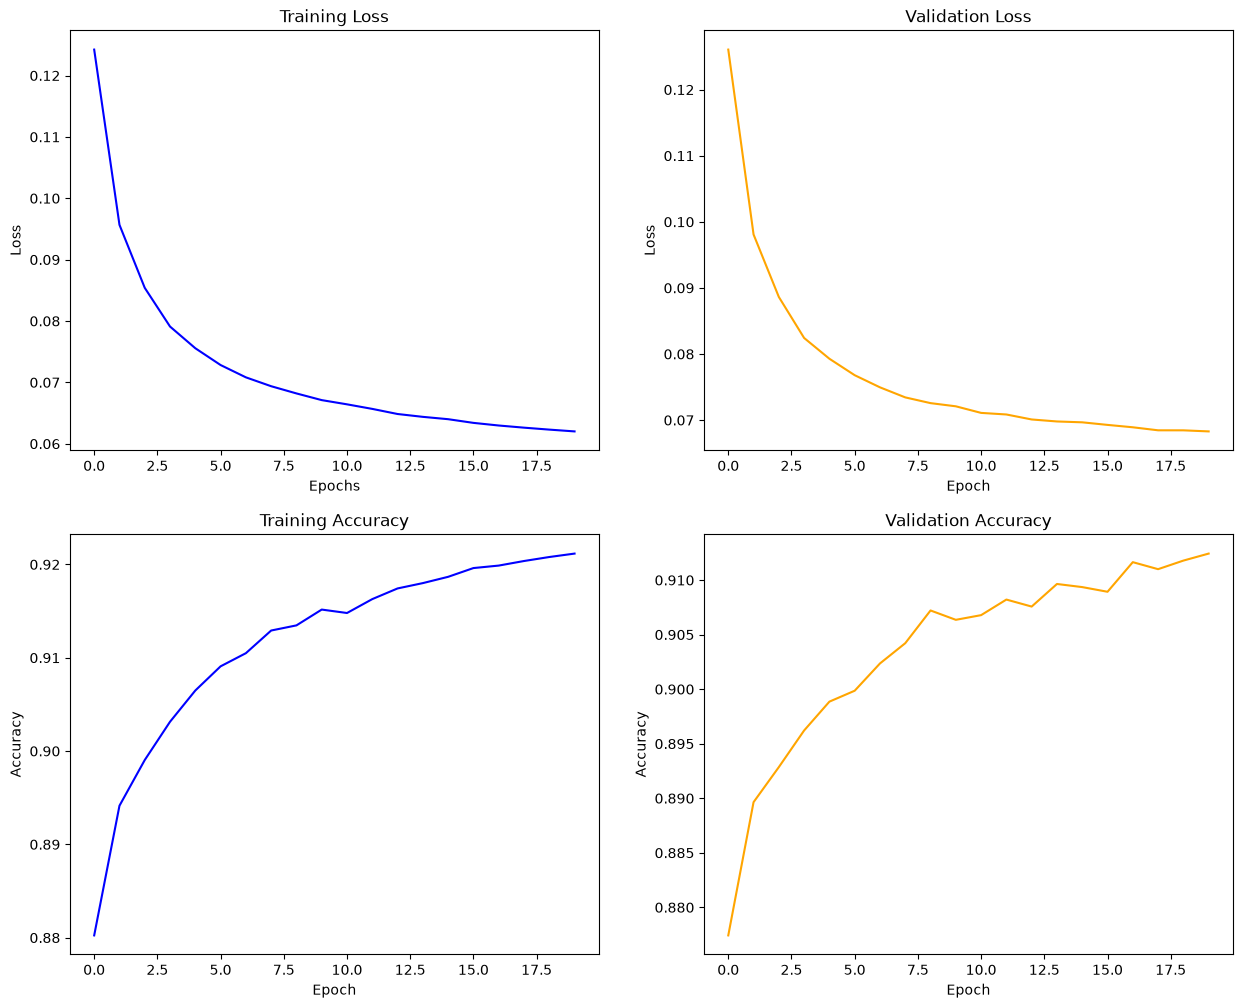

In [101]:
fig, (ax1, ax2) = plt.subplots(2, 2, figsize=(15, 12))

ax1[0].plot(train_losses, color='blue')
ax1[0].set_title('Training Loss')
ax1[0].set_xlabel('Epochs')
ax1[0].set_ylabel('Loss')

ax1[1].plot(val_losses, color='orange')
ax1[1].set_title('Validation Loss')
ax1[1].set_xlabel('Epoch')
ax1[1].set_ylabel('Loss')

ax2[0].plot(train_accs, color='blue')
ax2[0].set_title('Training Accuracy')
ax2[0].set_xlabel('Epoch')
ax2[0].set_ylabel('Accuracy')

ax2[1].plot(val_accs, color='orange')
ax2[1].set_title('Validation Accuracy')
ax2[1].set_xlabel('Epoch')
ax2[1].set_ylabel('Accuracy')


plt.show()
